Dataset extracted successfully!
Classes found: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


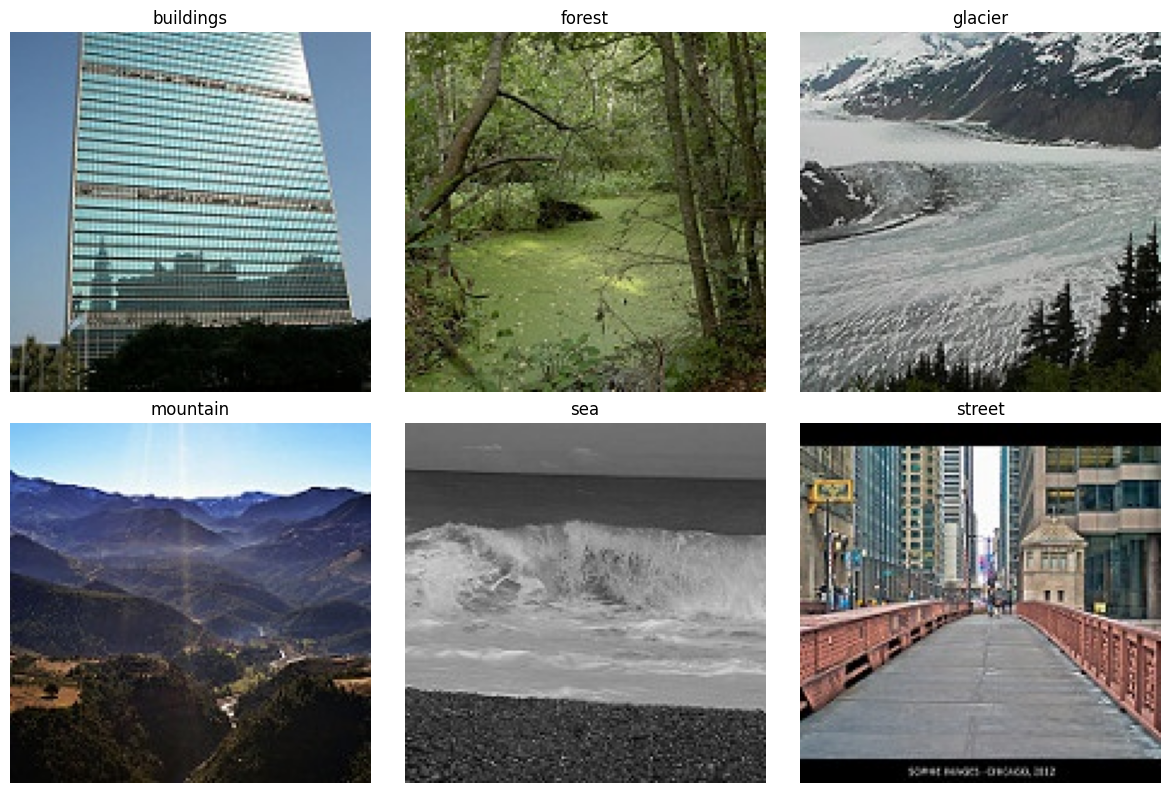

buildings : 2191 images
forest : 2271 images
glacier : 2404 images
mountain : 2512 images
sea : 2274 images
street : 2382 images


In [6]:
import zipfile
import os
import matplotlib.pyplot as plt
import cv2
import random

# UNZIP DATASET
# Путь к zip файлу
zip_path = r"C:\Users\Huawei\Downloads\archive (10).zip"

# Куда распаковать
extract_path = r"C:\Users\Huawei\Downloads\intel_dataset"

# Распаковка
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

# SET TRAIN PATH
train_path = os.path.join(extract_path, "seg_train", "seg_train")
# CHECK CLASSE
classes = os.listdir(train_path)
print("Classes found:", classes)
# VISUALIZE SAMPLE IMAGES
plt.figure(figsize=(12, 8))
for i, cls in enumerate(classes):
    class_path = os.path.join(train_path, cls)
    
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

# DATA INSIGHT
# Количество изображений в каждом классе
for cls in classes:
    path = os.path.join(train_path, cls)
    print(cls, ":", len(os.listdir(path)), "images")

# COMMENT:
# This step:
# - loads dataset from ZIP file
# - extracts it
# - explores class structure
# - visualizes sample images
# - checks dataset balance 

Found 12632 images belonging to 6 classes.
Found 1402 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)                  │ (None, 67500)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 512)                 │      34,560,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,693,382 (132.34 MB)

 Trainable params: 34,693,382 (132.34 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 464s 1s/step - accuracy: 0.6246 - loss: 0.9878 - val_accuracy: 0.7404 - val_loss: 0.7258
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 317s 698ms/step - accuracy: 0.7665 - loss: 0.6405 - val_accuracy: 0.7468 - val_loss: 0.6904
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 327s 712ms/step - accuracy: 0.8167 - loss: 0.4934 - val_accuracy: 0.7924 - val_loss: 0.5798
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 286s 724ms/step - accuracy: 0.8666 - loss: 0.3619 - val_accuracy: 0.8117 - val_loss: 0.5518
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 290s 735ms/step - accuracy: 0.9245 - loss: 0.2127 - val_accuracy: 0.8217 - val_loss: 0.6507
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 290s 733ms/step - accuracy: 0.9497 - loss: 0.1507 - val_accuracy: 0.8138 - val_loss: 0.7686
Epoch 7/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 284s 720ms/step - accuracy: 0.9752 - loss: 0.0808 - val_accuracy: 0.7960 - val_loss: 0.9531
Epoch 8/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 284s 718ms/step - accuracy: 0.9820 - lo

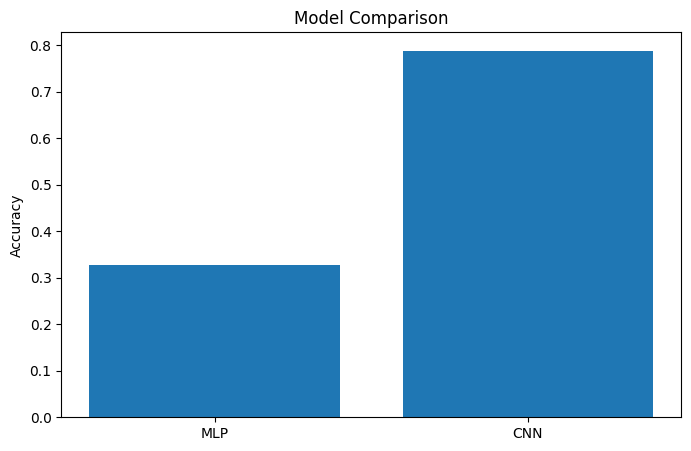

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

extract_path = r"C:\Users\Huawei\Downloads\intel_dataset"

train_path = os.path.join(extract_path, "seg_train", "seg_train")
test_path = os.path.join(extract_path, "seg_test", "seg_test")

IMG_SIZE = (150,150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1
)

test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

from tensorflow.keras import layers, models

def build_cnn():
    model = models.Sequential()

    model.add(layers.Input(shape=(150,150,3)))

    model.add(layers.Conv2D(32, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D(2,2))

    model.add(layers.Conv2D(64, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D(2,2))

    model.add(layers.Conv2D(128, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D(2,2))

    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dense(6, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

def build_mlp():
    model = models.Sequential()

    # flatten image → vector
    model.add(layers.Flatten(input_shape=(150,150,3)))

    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.3))

    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.3))

    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp_model = build_mlp()
mlp_model.summary()

history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

history_mlp = mlp_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)
cnn_loss, cnn_acc = cnn_model.evaluate(test_generator)
mlp_loss, mlp_acc = mlp_model.evaluate(test_generator)

print("CNN Accuracy:", cnn_acc)
print("MLP Accuracy:", mlp_acc)

plt.figure(figsize=(8,5))

plt.bar(["MLP", "CNN"], [mlp_acc, cnn_acc])

plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()


Found 12632 images belonging to 6 classes.
Found 1402 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 148, 148, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 72, 72, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 34, 34, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      18,940,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │           3,078 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,037,638 (72.62 MB)

 Trainable params: 19,037,190 (72.62 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 475s 1s/step - accuracy: 0.4550 - loss: 3.5298 - val_accuracy: 0.3438 - val_loss: 2.1332
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 500s 1s/step - accuracy: 0.5218 - loss: 1.2472 - val_accuracy: 0.5036 - val_loss: 1.3678
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 476s 1s/step - accuracy: 0.5465 - loss: 1.1905 - val_accuracy: 0.5357 - val_loss: 1.2072
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 468s 1s/step - accuracy: 0.5844 - loss: 1.0993 - val_accuracy: 0.4757 - val_loss: 1.7059
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 478s 1s/step - accuracy: 0.6059 - loss: 1.0668 - val_accuracy: 0.5842 - val_loss: 1.1172
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 504s 1s/step - accuracy: 0.6175 - loss: 1.0409 - val_accuracy: 0.6505 - val_loss: 1.0044
Epoch 7/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 501s 1s/step - accuracy: 0.6231 - loss: 1.0158 - val_accuracy: 0.6191 - val_loss: 1.0012
Epoch 8/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 482s 1s/step - accuracy: 0.6427 - loss: 0.9865 - val_accu

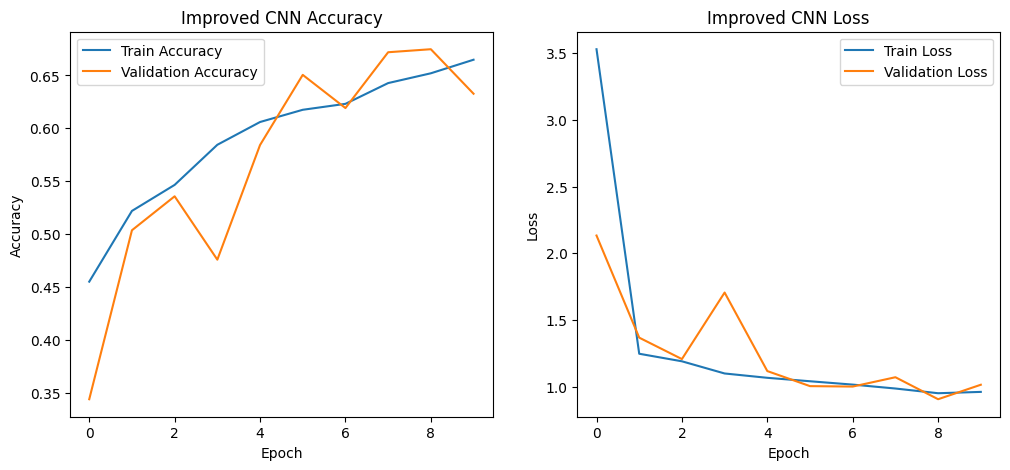

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step


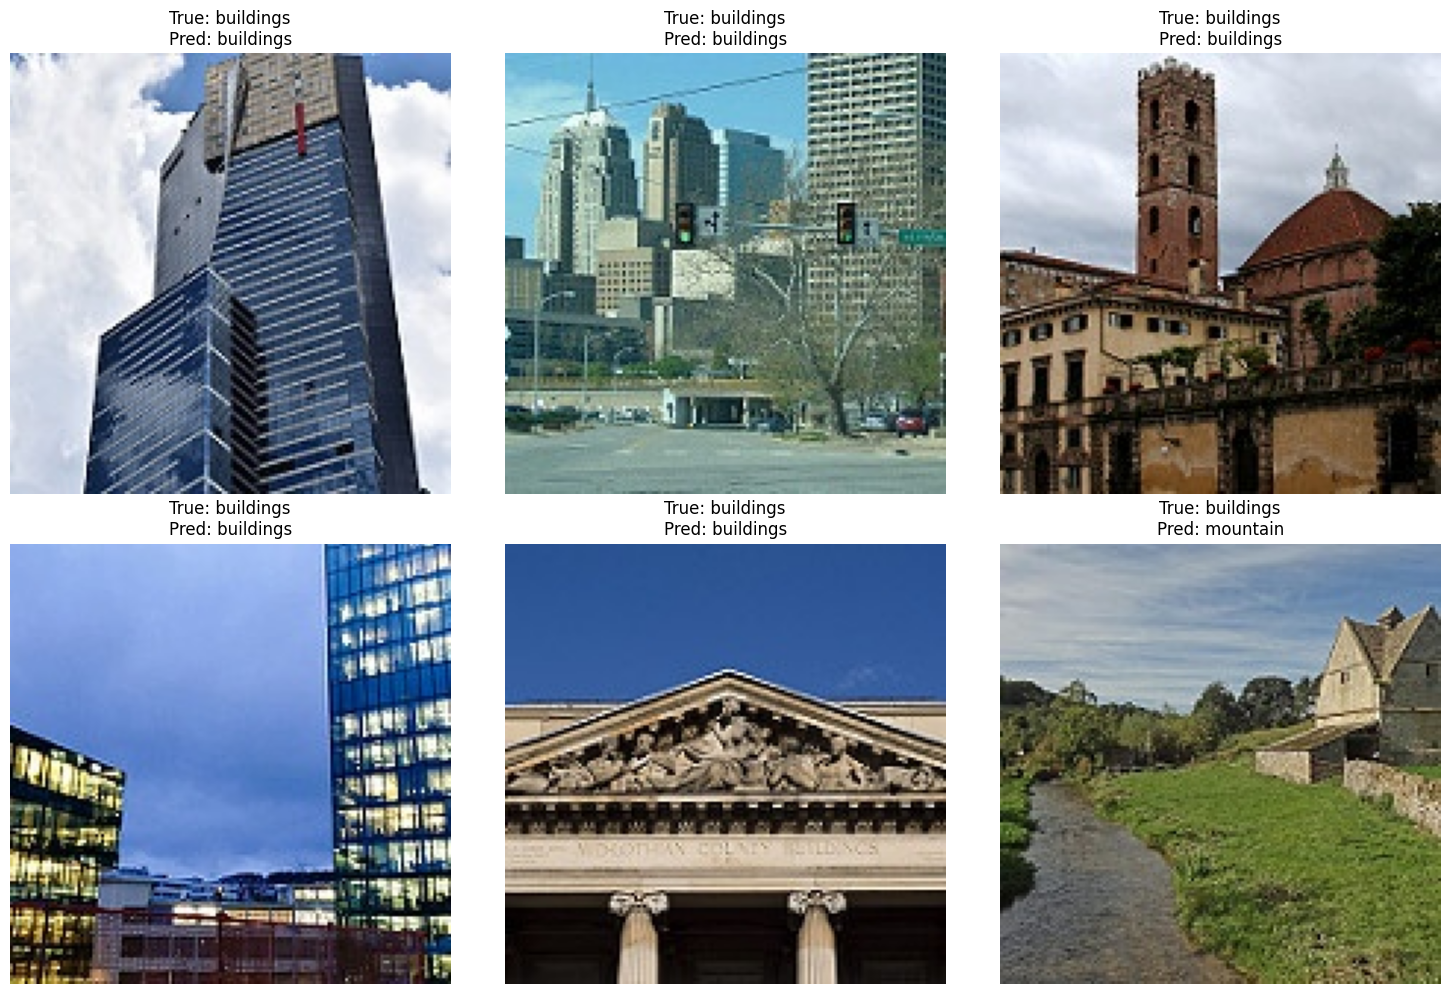

In [2]:
# IMPROVED CNN

# IMPORTS
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import matplotlib.pyplot as plt
import numpy as np
import os

# DATASET PATHS

extract_path = r"C:\Users\Huawei\Downloads\intel_dataset"

train_path = os.path.join(extract_path, "seg_train", "seg_train")
test_path = os.path.join(extract_path, "seg_test", "seg_test")

# IMAGE SETTINGS

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
NUM_CLASSES = 6

# DATA AUGMENTATION

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1,

    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

# DATA GENERATORS

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# IMPROVED CNN MODEL

def build_improved_cnn():

    model = models.Sequential()

    model.add(layers.Input(shape=(150,150,3)))

    # BLOCK 1
    model.add(layers.Conv2D(32, (3,3), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2,2))

    # BLOCK 2
    model.add(layers.Conv2D(64, (3,3), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2,2))

    # BLOCK 3
    model.add(layers.Conv2D(128, (3,3), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2,2))

    # CLASSIFIER
    model.add(layers.Flatten())

    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

    # COMPILE
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# BUILD MODEL
improved_cnn = build_improved_cnn()

# MODEL SUMMARY
improved_cnn.summary()

# TRAIN MODEL

history_improved = improved_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

# EVALUATE MODEL

test_loss, test_acc = improved_cnn.evaluate(test_generator)

print("\nImproved CNN Test Accuracy:", test_acc)
print("Improved CNN Test Loss:", test_loss)

# ACCURACY GRAPH

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history_improved.history['accuracy'], label='Train Accuracy')
plt.plot(history_improved.history['val_accuracy'], label='Validation Accuracy')

plt.title("Improved CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

# LOSS GRAPH

plt.subplot(1,2,2)

plt.plot(history_improved.history['loss'], label='Train Loss')
plt.plot(history_improved.history['val_loss'], label='Validation Loss')

plt.title("Improved CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

# SAMPLE PREDICTIONS

class_names = list(train_generator.class_indices.keys())

images, labels = next(test_generator)

predictions = improved_cnn.predict(images)
predicted_classes = np.argmax(predictions, axis=1)

plt.figure(figsize=(15,10))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i])

    true_label = class_names[np.argmax(labels[i])]
    predicted_label = class_names[predicted_classes[i]]

    plt.title(f"True: {true_label}\nPred: {predicted_label}")

    plt.axis("off")

plt.tight_layout()
plt.show()
